In [1]:
import importlib.util, sys
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42


In [3]:
ADATA_PATH       = Path('/lustre/scratch125/cellgen/vento/mm58/eutopic_endometrium/build_eutopic_object/integrated_scvi_uterus.h5ad')
ANNOTATIONS_PATH = Path('/nfs/team292/projects/PanTissue/results/freeze/annotations/concatenated_annotations_postnatal_v2.csv')
EPI_TACCO_DIR    = Path('/lustre/scratch125/cellgen/vento/mm58/eutopic_endometrium/mapping_epithelial_all/tacco_annotation_ensembl')
MESEN_TACCO_DIR  = Path('/lustre/scratch125/cellgen/vento/mm58/eutopic_endometrium/mapping_mesenchyme_all/tacco_annotation_ensembl')
SCORE_THRESHOLD  = 0.4
# BIN_ORDER        = ['basalis_1', 'basalis_2', 'functionalis_1', 'functionalis_2', 'functionalis_3', 'lumen_1']
BIN_ORDER        = [
    'lumen_1', 'functionalis_3','functionalis_2', 'functionalis_1',
    'basalis_2', 'basalis_1', 
    ]

## Load panatlas utils

In [4]:
spec = importlib.util.spec_from_file_location(
    'panatlas_utils',
    '/nfs/team292/projects/PanTissue/code/working/lg18/utils/panatlas_utils.py'
)
panatlas_utils = importlib.util.module_from_spec(spec)
sys.modules['panatlas_utils'] = panatlas_utils
spec.loader.exec_module(panatlas_utils)

from panatlas_utils import quick_markers, filterTFIDF

## Load integrated scRNA-seq object

In [5]:
adata = sc.read(ADATA_PATH)
print(adata)

AnnData object with n_obs × n_vars = 960115 × 35103
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'predicted_doublet', 'Menstrual_stage_short', 'leiden', 'fine_celltype', 'broad_celltype', 'lineage'
    var: 'in_inner

## Load TACCO predictions from epithelium and stromal fibs

In [6]:
def load_tacco(tacco_dir):
    pred_files  = sorted(tacco_dir.glob('*/tacco_predictions.csv'))
    score_files = sorted(tacco_dir.glob('*/tacco_scores_ensemble.parquet'))

    preds  = pd.concat([pd.read_csv(f).set_index('cell_id') for f in pred_files])
    scores = pd.concat([pd.read_parquet(f) for f in score_files])
    # drop duplicate indices (cells present in multiple stage runs)
    preds  = preds[~preds.index.duplicated(keep='first')]
    scores = scores[~scores.index.duplicated(keep='first')]
    return preds, scores

epi_preds,   epi_scores   = load_tacco(EPI_TACCO_DIR)
mesen_preds, mesen_scores = load_tacco(MESEN_TACCO_DIR)

print(f'Epi   predictions : {len(epi_preds):,} cells')
print(f'Mesen predictions : {len(mesen_preds):,} cells')

Epi   predictions : 148,078 cells
Mesen predictions : 543,010 cells


In [7]:
# Combine epi + mesen predictions and scores
all_preds  = pd.concat([epi_preds, mesen_preds])
all_scores = pd.concat([epi_scores, mesen_scores])

all_preds  = all_preds[~all_preds.index.duplicated(keep='first')]
all_scores = all_scores[~all_scores.index.duplicated(keep='first')]

print(f'Combined predictions: {len(all_preds):,} cells')

Combined predictions: 691,088 cells


## Add TACCO axis_bin and scores to adata, filter score < 0.5

In [8]:
adata.obs = adata.obs.join(all_preds[['axis_bin']], how='left')
adata.obs = adata.obs.join(all_scores, how='left')

adata.obs['axis_bin'] = np.where(
    adata.obs['fine_celltype'].str.contains('pericyte', case = False, na = False),
    np.nan,
    adata.obs['axis_bin'] 
)

score_cols = [c for c in BIN_ORDER if c in adata.obs.columns]
adata.obs['tacco_max_score'] = adata.obs[score_cols].max(axis=1)

print(f'Cells with TACCO prediction : {adata.obs["axis_bin"].notna().sum():,}')
print(f'axis_bin distribution:')
print(adata.obs['axis_bin'].value_counts(dropna=False))

Cells with TACCO prediction : 651,653
axis_bin distribution:
axis_bin
NaN               308462
functionalis_3    145524
basalis_2         133039
functionalis_2    124716
basalis_1         121576
functionalis_1    101065
lumen_1            25733
Name: count, dtype: int64


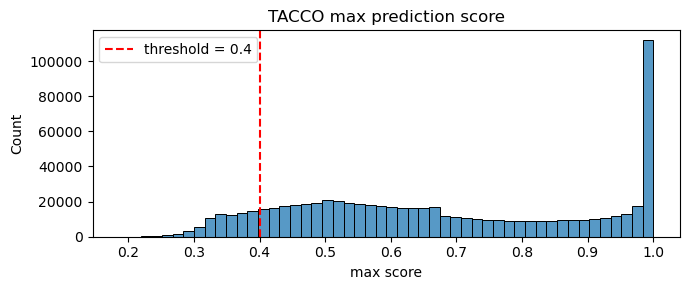

Removed 347,466 low-confidence cells (max score < 0.4)
Cells remaining: 612,649


In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(adata.obs['tacco_max_score'].dropna(), bins=50, ax=ax)
ax.axvline(SCORE_THRESHOLD, color='red', linestyle='--', label=f'threshold = {SCORE_THRESHOLD}')
ax.set_title('TACCO max prediction score')
ax.set_xlabel('max score')
ax.legend()
plt.tight_layout()
plt.show()

n_before = adata.n_obs
mask = adata.obs['tacco_max_score'] >= SCORE_THRESHOLD
adata = adata[mask].copy()
print(f'Removed {n_before - adata.n_obs:,} low-confidence cells (max score < {SCORE_THRESHOLD})')
print(f'Cells remaining: {adata.n_obs:,}')

## Create lineage_bin variable

In [10]:
adata.obs['lineage_bin'] = adata.obs['lineage'].astype(str) + '_' + adata.obs['axis_bin'].astype(str)

print(f'lineage_bin value counts:')
print(adata.obs['lineage_bin'].value_counts(dropna=False))

lineage_bin value counts:
lineage_bin
mesenchymal_functionalis_3    110871
mesenchymal_basalis_2          92857
mesenchymal_basalis_1          86462
mesenchymal_functionalis_2     80129
mesenchymal_functionalis_1     68267
mesenchymal_nan                37525
epithelial_basalis_2           26104
epithelial_functionalis_2      25857
epithelial_basalis_1           21817
epithelial_functionalis_3      20946
epithelial_lumen_1             19563
epithelial_functionalis_1      19320
mesenchymal_lumen_1             2931
Name: count, dtype: int64


## UMAP coloured by lineage_bin and axis_bin

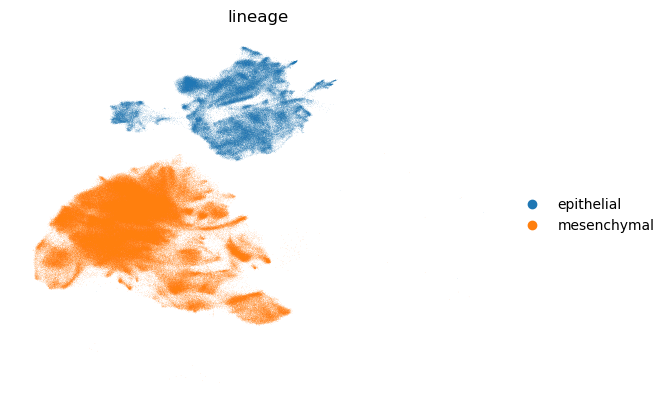

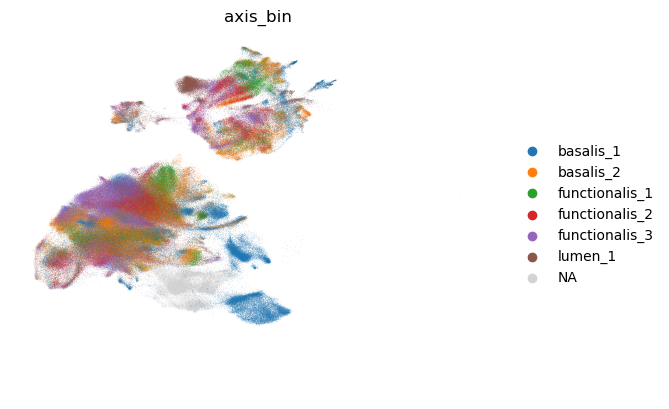

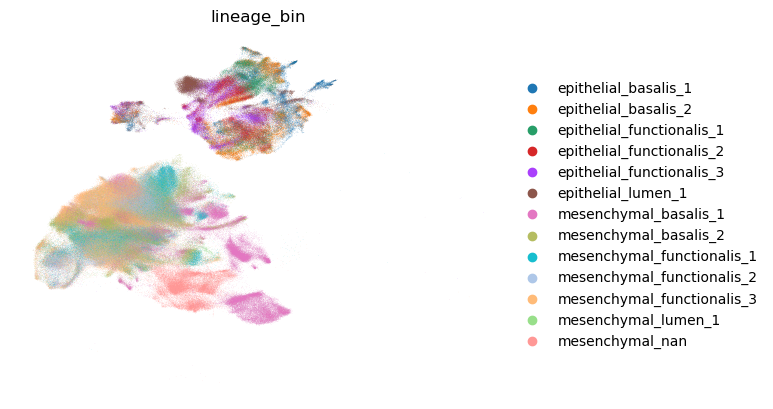

In [11]:
sc.pl.umap(adata, color='lineage',   frameon=False)
sc.pl.umap(adata, color='axis_bin',  frameon=False)
sc.pl.umap(adata, color='lineage_bin', frameon=False)

In [12]:
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Export hedgehog

In [13]:
hedgehog_signalling_genes = [
    "PTCH1",
    "PTCH2",
    "GLI1",
    "GLI2",
    "GLI3",
    "HHIP",
    "SMO",
    "SUFU",
    "GPR161",
    "KIF7",
    "EVC",
    "EVC2",
]

In [14]:
adata.obs["lineage"].value_counts()

lineage
mesenchymal    479042
epithelial     133607
Name: count, dtype: int64

In [15]:
adata.obs['axis_bin'] = pd.Categorical(
    adata.obs['axis_bin'],
    categories = BIN_ORDER,
    ordered = True
)

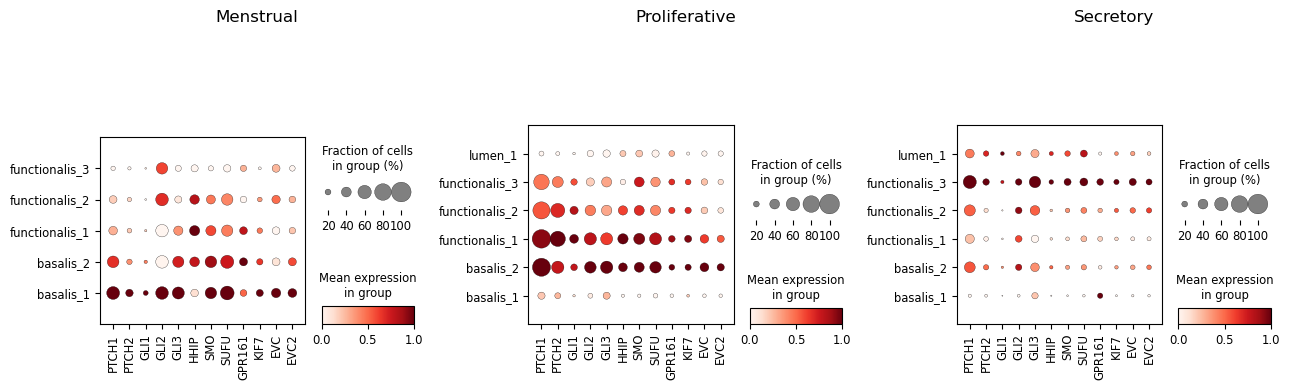

In [16]:
import matplotlib.pyplot as plt
import scanpy as sc

stages = ["Menstrual", "Proliferative", "Secretory", ]

fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 4),
    sharey=True
)

for ax, stage in zip(axes, stages):

    subset = adata[
        (adata.obs["lineage"] == "mesenchymal") &
        (adata.obs["Menstrual_stage_short"] == stage)
    ]

    sc.pl.dotplot(
        subset,
        hedgehog_signalling_genes,
        groupby="axis_bin",
        standard_scale="var",
        ax=ax,
        show=False,
        dot_max=1.0,   # 100% expressing cells
        dot_min=0.0,
        smallest_dot=0,
    )

    ax.set_title(stage)

plt.tight_layout()
plt.savefig('hh_mesen.pdf')
plt.show()

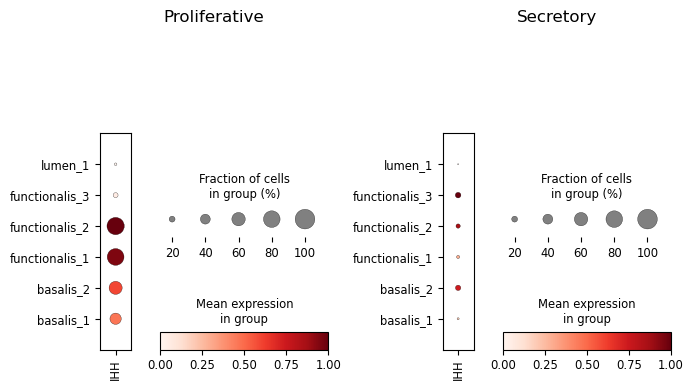

In [17]:
stages = ["Proliferative", "Secretory",]

fig, axes = plt.subplots(
    1, 2,
    figsize=(7, 4),
    sharey=True
)

for ax, stage in zip(axes, stages):

    subset = adata[
        (adata.obs["lineage"] == "epithelial") &
        (adata.obs["Menstrual_stage_short"] == stage)
    ]

    sc.pl.dotplot(
        subset,
        ['IHH'],
        groupby="axis_bin",
        standard_scale="var",
        ax=ax,
        show=False,
        dot_max=1.0,   # 100% expressing cells
        dot_min=0.0,
    )

    ax.set_title(stage)

plt.tight_layout()
plt.savefig('hh_epi.pdf')
plt.show()

/tmp/ipykernel_1537215/2307156084.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


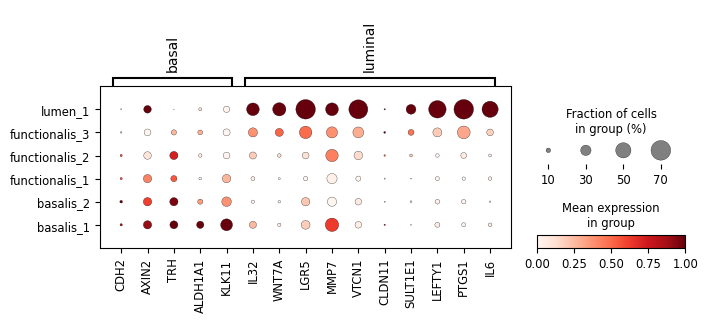

In [18]:
sc.pl.dotplot(
    adata[adata.obs['lineage'] == 'epithelial'],
    {
        'basal' : ['CDH2', 'AXIN2', 'TRH', 'ALDH1A1', 'KLK11'],
        'luminal' : ['IL32', 'WNT7A', 'LGR5', 'MMP7', 'VTCN1', 'CLDN11', 'SULT1E1', 'LEFTY1', 'PTGS1', 'IL6'],
    },
    groupby = 'axis_bin', 
    standard_scale = 'var',
    save = 'heca_genes.pdf'
)
